**Majid**

In [ ]:
 # Cell 1: Install Required Dependencies
# ===============================================

!pip install kagglehub
!pip install opencv-python-headless
!pip install scikit-learn
!pip install seaborn
!pip install matplotlib
!pip install tensorflow
!pip install tqdm

print(" All dependencies installed successfully!")

 All dependencies installed successfully!


In [ ]:
# Cell 2: Import Libraries and Configuration
# ===============================================

import kagglehub
import os
import shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdmq
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import seaborn as sns
import pandas as pd
import glob
import warnings
import gc
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configuration
CONFIG = {
    'IMG_SIZE': (224, 224),
    'BATCH_SIZE': 16,  # Reduced for Colab
    'EPOCHS': 15,      # Reduced for faster training
    'FINE_TUNE_EPOCHS': 10,
    'LEARNING_RATE': 0.001,
    'FINE_TUNE_LR': 0.0001,
    'TRAIN_SPLIT': 0.7,
    'VAL_SPLIT': 0.15,
    'TEST_SPLIT': 0.15,
    'PATIENCE': 5,
    'DISEASE_THRESHOLD': 0.1,
    'RANDOM_STATE': 42
}

# Paths
PATHS = {
    'BASE_DIR': '/content/tobacco_classification',
    'SOURCE_ROOT': None,
    'MERGED_ROOT': '/content/tobacco_classification/merged_data',
    'FINAL_ROOT': '/content/tobacco_classification/final_data',
    'MODELS_DIR': '/content/tobacco_classification/models',
    'RESULTS_DIR': '/content/tobacco_classification/results'
}

# Create directories
for path in PATHS.values():
    if path and path != PATHS['SOURCE_ROOT']:
        os.makedirs(path, exist_ok=True)

print(" Configuration and directories setup complete!")

 Configuration and directories setup complete!


In [ ]:
# Cell 3: Data Download and Safe File Operations
# ===============================================

def safe_copy_file(src, dst, max_retries=3):
    """Safely copy file with proper resource management"""
    for attempt in range(max_retries):
        try:
            # Ensure destination directory exists
            os.makedirs(os.path.dirname(dst), exist_ok=True)

            # Copy file with explicit resource management
            with open(src, 'rb') as fsrc:
                with open(dst, 'wb') as fdst:
                    shutil.copyfileobj(fsrc, fdst, 65536)  # 64KB chunks
            return True
        except Exception as e:
            if attempt == max_retries - 1:
                print(f" Failed to copy {src}: {e}")
                return False
            continue
    return False

def download_dataset():
    """Download tobacco leaf dataset from KaggleHub"""
    try:
        print(" Downloading tobacco leaf disease dataset...")
        path = kagglehub.dataset_download("chzili/dataset-for-tobacco-leaf-disease-segmentation")
        print(f" Downloaded to: {path}")

        # List contents
        if os.path.exists(path):
            contents = os.listdir(path)
            print(f" Contents: {contents}")
            return path
        else:
            print(" Download path not found")
            return None

    except Exception as e:
        print(f" Error downloading dataset: {e}")
        return None

# Download dataset
source_path = download_dataset()
if source_path:
    PATHS['SOURCE_ROOT'] = source_path
    print(f" Dataset ready at: {source_path}")
else:
    print(" Failed to download dataset")

print(" Data download setup complete!")

100%|██████████| 2.56G/2.56G [00:17<00:00, 157MB/s]

Extracting files...


 Downloaded to: /root/.cache/kagglehub/datasets/chzili/dataset-for-tobacco-leaf-disease-segmentation/versions/1
 Contents: ['data2', 'data1']
 Dataset ready at: /root/.cache/kagglehub/datasets/chzili/dataset-for-tobacco-leaf-disease-segmentation/versions/1
 Data download setup complete!


In [ ]:
# Cell 4: Data Processing Functions
# ===============================================

def is_diseased_mask(mask_path, threshold=CONFIG['DISEASE_THRESHOLD']):
    """Determine if a mask indicates disease based on non-black pixel ratio"""
    try:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            return False

        non_black = cv2.countNonZero(mask)
        ratio = non_black / (mask.shape[0] * mask.shape[1])
        return ratio > threshold
    except Exception as e:
        return False

def process_dataset_batch(file_list, source_dir, target_healthy, target_diseased, batch_size=100):
    """Process files in batches to avoid memory issues"""
    healthy_count = 0
    diseased_count = 0
    error_count = 0

    for i in range(0, len(file_list), batch_size):
        batch = file_list[i:i+batch_size]
        print(f"Processing batch {i//batch_size + 1}/{(len(file_list)-1)//batch_size + 1}")

        for fname in tqdm(batch, desc=f"Batch {i//batch_size + 1}"):
            img_path = os.path.join(source_dir, "imgs", fname)
            mask_path = os.path.join(source_dir, "masks", fname)

            if not os.path.exists(img_path) or not os.path.exists(mask_path):
                continue

            try:
                if is_diseased_mask(mask_path):
                    if safe_copy_file(img_path, os.path.join(target_diseased, fname)):
                        diseased_count += 1
                else:
                    if safe_copy_file(img_path, os.path.join(target_healthy, fname)):
                        healthy_count += 1
            except Exception as e:
                error_count += 1

        # Force garbage collection after each batch
        gc.collect()

    return healthy_count, diseased_count, error_count

def organize_tobacco_data(source_path):
    """Organize tobacco data with safe file handling"""
    print(" Organizing tobacco leaf data...")

    # Create target directories
    healthy_dir = os.path.join(PATHS['MERGED_ROOT'], 'healthy')
    diseased_dir = os.path.join(PATHS['MERGED_ROOT'], 'diseased')
    os.makedirs(healthy_dir, exist_ok=True)
    os.makedirs(diseased_dir, exist_ok=True)

    total_healthy = 0
    total_diseased = 0
    total_errors = 0

    # Look for data directories
    data_dirs = []
    for root, dirs, files in os.walk(source_path):
        if 'imgs' in dirs and 'masks' in dirs:
            data_dirs.append(root)

    print(f"Found {len(data_dirs)} data directories")

    for data_dir in data_dirs:
        imgs_dir = os.path.join(data_dir, "imgs")

        if not os.path.exists(imgs_dir):
            continue

        print(f" Processing {data_dir}...")
        image_files = [f for f in os.listdir(imgs_dir)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if not image_files:
            continue

        h_count, d_count, e_count = process_dataset_batch(
            image_files, data_dir, healthy_dir, diseased_dir
        )

        total_healthy += h_count
        total_diseased += d_count
        total_errors += e_count

    print(f" Data organization complete!")
    print(f"    Healthy leaves: {total_healthy}")
    print(f"    Diseased leaves: {total_diseased}")
    print(f"    Errors: {total_errors}")

    return total_healthy, total_diseased

# Execute data organization
if PATHS['SOURCE_ROOT']:
    healthy_count, diseased_count = organize_tobacco_data(PATHS['SOURCE_ROOT'])
else:
    print(" No source data available")

print(" Data processing complete!")

 Organizing tobacco leaf data...
Found 2 data directories
 Processing /root/.cache/kagglehub/datasets/chzili/dataset-for-tobacco-leaf-disease-segmentation/versions/1/data2/data...
Processing batch 1/15


Batch 1: 100%|██████████| 100/100 [00:00<00:00, 181.47it/s]


Processing batch 2/15


Batch 2: 100%|██████████| 100/100 [00:00<00:00, 194.86it/s]


Processing batch 3/15


...

Processing batch 19/20


Batch 19: 100%|██████████| 100/100 [00:00<00:00, 109.54it/s]


Processing batch 20/20


Batch 20: 100%|██████████| 100/100 [00:00<00:00, 126.12it/s]


 Data organization complete!
    Healthy leaves: 3331
    Diseased leaves: 169
    Errors: 0
 Data processing complete!


In [ ]:
# Cell 5: Image Preprocessing
# ===============================================

def apply_clahe(image):
    """Apply CLAHE for contrast enhancement"""
    try:
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        lab[:,:,0] = clahe.apply(lab[:,:,0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    except:
        return image

def preprocess_images_batch(source_dir, target_dir, batch_size=50):
    """Preprocess images in batches to avoid memory issues"""
    if not os.path.exists(source_dir):
        print(f" Source directory not found: {source_dir}")
        return 0, 0

    os.makedirs(target_dir, exist_ok=True)

    image_files = [f for f in os.listdir(source_dir)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not image_files:
        print(f" No images found in {source_dir}")
        return 0, 0

    processed_count = 0
    error_count = 0

    for i in range(0, len(image_files), batch_size):
        batch = image_files[i:i+batch_size]
        print(f"Processing batch {i//batch_size + 1}/{(len(image_files)-1)//batch_size + 1}")

        for fname in tqdm(batch, desc=f"Preprocessing batch {i//batch_size + 1}"):
            img_path = os.path.join(source_dir, fname)

            try:
                # Read and preprocess image
                img = cv2.imread(img_path)
                if img is None:
                    error_count += 1
                    continue

                # Resize to target size
                img = cv2.resize(img, CONFIG['IMG_SIZE'])

                # Apply contrast enhancement
                img = apply_clahe(img)

                # Save processed image
                save_path = os.path.join(target_dir, fname)
                cv2.imwrite(save_path, img)
                processed_count += 1

            except Exception as e:
                error_count += 1

        # Force garbage collection
        gc.collect()

    print(f" Processed {processed_count} images, {error_count} errors")
    return processed_count, error_count

# Preprocess images for both classes
for cls in ['healthy', 'diseased']:
    source_path = os.path.join(PATHS['MERGED_ROOT'], cls)
    target_path = os.path.join(PATHS['FINAL_ROOT'], cls)

    print(f"\n Preprocessing {cls} images...")
    processed, errors = preprocess_images_batch(source_path, target_path)

print(" Image preprocessing complete!")


 Preprocessing healthy images...
Processing batch 1/67


Preprocessing batch 1: 100%|██████████| 50/50 [00:01<00:00, 40.23it/s]


Processing batch 2/67


Preprocessing batch 2: 100%|██████████| 50/50 [00:01<00:00, 35.11it/s]


Processing batch 3/67


...

Processing batch 3/4


Preprocessing batch 3: 100%|██████████| 50/50 [00:01<00:00, 47.42it/s]


Processing batch 4/4


Preprocessing batch 4: 100%|██████████| 19/19 [00:00<00:00, 50.14it/s]

 Processed 169 images, 0 errors
 Image preprocessing complete!


In [ ]:
# Cell 6: Data Loading and Splitting
# ===============================================

def load_data_paths():
    """Load image paths and labels efficiently"""
    healthy_dir = os.path.join(PATHS['FINAL_ROOT'], 'healthy')
    diseased_dir = os.path.join(PATHS['FINAL_ROOT'], 'diseased')

    healthy_files = []
    diseased_files = []

    # Load healthy files
    if os.path.exists(healthy_dir):
        healthy_files = [os.path.join(healthy_dir, f) for f in os.listdir(healthy_dir)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Load diseased files
    if os.path.exists(diseased_dir):
        diseased_files = [os.path.join(diseased_dir, f) for f in os.listdir(diseased_dir)
                         if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Combine paths and labels
    X_paths = np.array(healthy_files + diseased_files)
    y_labels = np.array([0]*len(healthy_files) + [1]*len(diseased_files))

    # Shuffle data
    X_paths, y_labels = shuffle(X_paths, y_labels, random_state=CONFIG['RANDOM_STATE'])

    print(f" Data loaded:")
    print(f"    Total images: {len(X_paths)}")
    print(f"    Healthy: {len(healthy_files)}")
    print(f"    Diseased: {len(diseased_files)}")

    return X_paths, y_labels

def split_data(X_paths, y_labels):
    """Split data into train/val/test sets"""
    if len(X_paths) == 0:
        return None, None, None, None, None, None

    # First split: separate test set
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_paths, y_labels,
        test_size=CONFIG['TEST_SPLIT'],
        stratify=y_labels,
        random_state=CONFIG['RANDOM_STATE']
    )

    # Second split: train and validation
    val_size = CONFIG['VAL_SPLIT'] / (1 - CONFIG['TEST_SPLIT'])
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=val_size,
        stratify=y_temp,
        random_state=CONFIG['RANDOM_STATE']
    )

    print(f" Data split:")
    print(f"    Train: {len(X_train)} ({len(X_train)/len(X_paths)*100:.1f}%)")
    print(f"    Val: {len(X_val)} ({len(X_val)/len(X_paths)*100:.1f}%)")
    print(f"    Test: {len(X_test)} ({len(X_test)/len(X_paths)*100:.1f}%)")

    return X_train, X_val, X_test, y_train, y_val, y_test

# Load and split data
X_paths, y_labels = load_data_paths()

if len(X_paths) > 0:
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_paths, y_labels)
    print(" Data loading and splitting complete!")
else:
    print(" No data found for loading")
    X_train = X_val = X_test = y_train = y_val = y_test = None

 Data loaded:
    Total images: 3500
    Healthy: 3331
    Diseased: 169
 Data split:
    Train: 2450 (70.0%)
    Val: 525 (15.0%)
    Test: 525 (15.0%)
 Data loading and splitting complete!


 Creating datasets...
 Datasets created successfully!

 Sample data visualization:


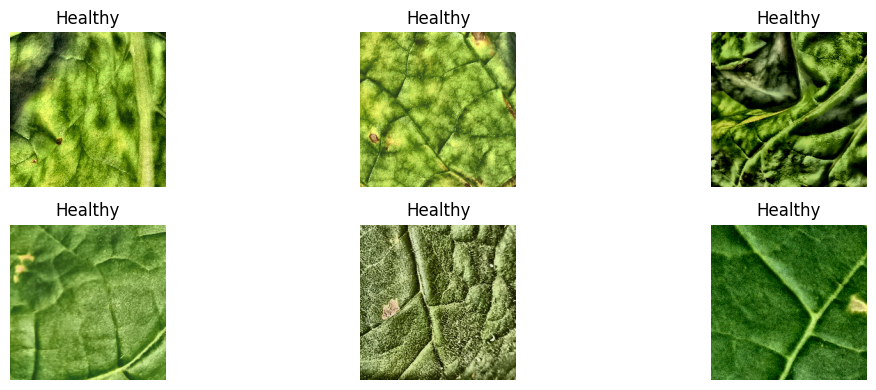

In [ ]:
# Cell 7: Data Generators and Augmentation
# ===============================================

def preprocess_image(path, label, augment=False):
    """Preprocess single image with memory management"""
    try:
        # Read and decode image
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.cast(img, tf.float32)
        img.set_shape([None, None, 3])

        # Resize and normalize
        img = tf.image.resize(img, CONFIG['IMG_SIZE'])
        img = img / 255.0

        # Apply augmentation if specified
        if augment:
            # Random horizontal flip
            img = tf.image.random_flip_left_right(img)
            # Random brightness
            img = tf.image.random_brightness(img, 0.2)
            # Random contrast
            img = tf.image.random_contrast(img, 0.8, 1.2)
            # Random rotation (simplified)
            img = tf.image.rot90(img, tf.random.uniform([], 0, 4, dtype=tf.int32))

        return img, label
    except:
        # Return zero tensor on error
        return tf.zeros([*CONFIG['IMG_SIZE'], 3], dtype=tf.float32), label

def create_dataset(paths, labels, augment=False, batch_size=None):
    """Create TensorFlow dataset with efficient loading"""
    if batch_size is None:
        batch_size = CONFIG['BATCH_SIZE']

    if paths is None or len(paths) == 0:
        return None

    # Create dataset
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    # Map preprocessing
    dataset = dataset.map(
        lambda x, y: preprocess_image(x, y, augment=augment),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Shuffle if augmenting (training)
    if augment:
        dataset = dataset.shuffle(min(1000, len(paths)))

    # Batch and prefetch
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

# Create datasets
if X_train is not None:
    print(" Creating datasets...")

    train_dataset = create_dataset(X_train, y_train, augment=True)
    val_dataset = create_dataset(X_val, y_val, augment=False)
    test_dataset = create_dataset(X_test, y_test, augment=False)

    print(" Datasets created successfully!")

    # Visualize a few samples
    print("\n Sample data visualization:")
    plt.figure(figsize=(12, 4))

    for i, (images, labels) in enumerate(train_dataset.take(1)):
        for j in range(min(6, images.shape[0])):
            plt.subplot(2, 3, j+1)
            plt.imshow(images[j])
            plt.title(f"{'Diseased' if labels[j] == 1 else 'Healthy'}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()

else:
    print(" No training data available for dataset creation")
    train_dataset = val_dataset = test_dataset = None

**Ahsan Nasir**

In [ ]:
# Cell 8: Model Architecture
# ===============================================

def build_tobacco_model(input_shape=(224, 224, 3)):
    """Build lightweight ResNet50-based model for tobacco leaf classification"""

    # Base model (frozen initially)
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False

    # Add custom classifier
    inputs = base_model.input
    x = base_model.output

    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)

    # Dense layers with dropout
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.3)(x)

    # Output layer
    outputs = layers.Dense(1, activation='sigmoid', name='predictions')(x)

    # Create model
    model = Model(inputs, outputs)

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=CONFIG['LEARNING_RATE']),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model

def create_callbacks():
    """Create training callbacks"""
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=CONFIG['PATIENCE'],
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]
    return callbacks

# Build model
if train_dataset is not None:
    print(" Building tobacco leaf disease classification model...")

    model, base_model = build_tobacco_model()

    print(f" Model built successfully!")
    print(f" Total parameters: {model.count_params():,}")
    print(f" Trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")

    # Display model summary (compact)
    model.summary()

else:
    print(" No training data available for model building")
    model = base_model = None

 Building tobacco leaf disease classification model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Model built successfully!
 Total parameters: 24,137,985
 Trainable parameters: 545,665


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,137,985 (92.08 MB)

 Trainable params: 545,665 (2.08 MB)

 Non-trainable params: 23,592,320 (90.00 MB)

In [ ]:
# === Complexity & Timing Helpers 9) ===
import time
import tensorflow as tf

class EpochTimer(tf.keras.callbacks.Callback):
    """Records wall-clock time per epoch in self.epoch_times."""
    def on_train_begin(self, logs=None):
        self.epoch_times = []
    def on_epoch_begin(self, epoch, logs=None):
        self._t0 = time.perf_counter()
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.perf_counter() - self._t0)

def describe_model_complexity(model, train_ds, epochs=None):
    """
    Prints practical info + rule-of-thumb Big-O for DL training.
    """
    print("=== Model Complexity Summary ===")
    try:
        print(f"Total trainable parameters: {model.count_params():,}")
    except Exception as e:
        print("Could not count params:", e)

    # Try to estimate steps/epoch and batch size
    try:
        steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
    except Exception:
        steps_per_epoch = None

    try:
        first_batch = next(iter(train_ds))
        x = first_batch[0] if isinstance(first_batch, (list, tuple)) else first_batch
        batch_size = int(x.shape[0])
    except Exception:
        batch_size = None

    samples = None
    if steps_per_epoch and batch_size:
        samples = steps_per_epoch * batch_size

    print(f"Steps/epoch: {steps_per_epoch}")
    print(f"Batch size (approx): {batch_size}")
    print(f"Samples/epoch (approx): {samples}")

    print("\n=== Asymptotic (Big-O) Guidance ===")
    print("Training per epoch: O(S × C)")
    print("  S = samples per epoch (≈ steps_per_epoch × batch_size)")
    print("  C = cost per sample (depends on layers)")
    print("    • Dense layers:   C ≈ Σ(n_in × n_out)")
    print("    • Conv2D layers:  C ≈ Σ(kH×kW×C_in×C_out×H_out×W_out)")
    print("Inference per sample: O(C)")
    if epochs is not None:
        print(f"Total training over {epochs} epoch(s): O(epochs × S × C)")


 Training tobacco leaf disease classification model...
 Starting model training...
=== Model Complexity Summary ===
Total trainable parameters: 24,137,985
Steps/epoch: 154
Batch size (approx): 16
Samples/epoch (approx): 2464

=== Asymptotic (Big-O) Guidance ===
Training per epoch: O(S × C)
  S = samples per epoch (≈ steps_per_epoch × batch_size)
  C = cost per sample (depends on layers)
    • Dense layers:   C ≈ Σ(n_in × n_out)
    • Conv2D layers:  C ≈ Σ(kH×kW×C_in×C_out×H_out×W_out)
Inference per sample: O(C)
Total training over 15 epoch(s): O(epochs × S × C)

 Phase 1: Training with frozen base model...
Epoch 1/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 42s 152ms/step - accuracy: 0.9229 - loss: 0.6115 - val_accuracy: 0.9524 - val_loss: 0.4703 - learning_rate: 0.0010
Epoch 2/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.9445 - loss: 0.4828 - val_accuracy: 0.9524 - val_loss: 0.4455 - learning_rate: 0.0010
Epoch 3/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.9478 - lo

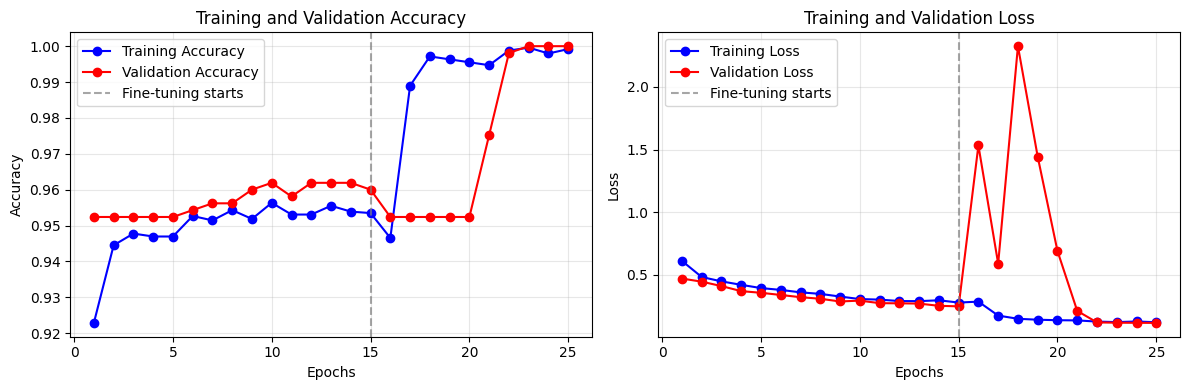

 Model saved to: /content/tobacco_classification/models/tobacco_model.h5


In [ ]:
# Cell 9: Model Training
# ===============================================

def train_model(model, base_model, train_ds, val_ds):
    """Train the tobacco leaf disease model (two phases: warm-up + fine-tune)."""
    print(" Starting model training...")

    # --- Complexity guidance (one-time, practical Big-O note) ---
    try:
        total_epochs = (
            CONFIG.get('EPOCHS') or
            (CONFIG.get('WARMUP_EPOCHS', 0) + CONFIG.get('FINE_TUNE_EPOCHS', 0))
        )
        describe_model_complexity(model, train_ds, epochs=total_epochs)
    except Exception:
        # Fall back if helper not available or datasets are generators without cardinality
        describe_model_complexity(model, train_ds)

    # -----------------------
    # Phase 1: Frozen base
    # -----------------------
    print("\n Phase 1: Training with frozen base model...")
    warmup_epochs = CONFIG.get('WARMUP_EPOCHS', CONFIG.get('EPOCHS', 5))

    callbacks_phase1 = list(create_callbacks())  # your existing callbacks factory
    timer1 = EpochTimer()
    callbacks_phase1.append(timer1)

    history1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=warmup_epochs,
        callbacks=callbacks_phase1,
        verbose=1
    )
    print("Phase 1 epoch times (s):", timer1.epoch_times)
    if timer1.epoch_times:
        print("Phase 1 avg epoch time (s):", sum(timer1.epoch_times) / len(timer1.epoch_times))

    # -----------------------
    # Phase 2: Fine-tuning
    # -----------------------
    print("\n Phase 2: Fine-tuning...")

    # Unfreeze the base model
    base_model.trainable = True

    # Re-compile with a lower LR for fine-tuning
    fine_lr = CONFIG.get('FINE_TUNE_LR', max(1e-6, CONFIG.get('LR', 1e-4) / 10.0))
    model.compile(
        optimizer=Adam(learning_rate=fine_lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    fine_tune_epochs = CONFIG.get('FINE_TUNE_EPOCHS', 5)

    callbacks_phase2 = list(create_callbacks())
    timer2 = EpochTimer()
    callbacks_phase2.append(timer2)

    history2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=fine_tune_epochs,
        callbacks=callbacks_phase2,
        verbose=1
    )
    print("Phase 2 epoch times (s):", timer2.epoch_times)
    if timer2.epoch_times:
        print("Phase 2 avg epoch time (s):", sum(timer2.epoch_times) / len(timer2.epoch_times))

    return history1, history2


def plot_training_history(history1, history2):
    """Plot training & validation accuracy/loss across both phases."""
    # Combine histories
    acc = history1.history['accuracy'] + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss = history1.history['loss'] + history2.history['loss']
    val_loss = history1.history['val_loss'] + history2.history['val_loss']

    epochs = range(1, len(acc) + 1)
    phase1_end = len(history1.history['accuracy'])

    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning starts')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning starts')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Train the model
if model is not None and train_dataset is not None:
    # Clear any existing graphs/models
    tf.keras.backend.clear_session()
    gc.collect()

    print(" Training tobacco leaf disease classification model...")

    history1, history2 = train_model(model, base_model, train_dataset, val_dataset)

    print(" Training completed!")

    # Plot training curves
    plot_training_history(history1, history2)

    # Save model
    model_path = os.path.join(PATHS['MODELS_DIR'], 'tobacco_model.h5')
    model.save(model_path)
    print(f" Model saved to: {model_path}")
else:
    print(" Cannot train model - missing model or data")
    history1 = history2 = None


**Mohammad Abbas**

 Evaluating trained model...

 Evaluating model on Validation set...

 Validation Results:
    Accuracy:  1.0000
    Precision: 1.0000
    Recall:    1.0000
    F1-Score:  1.0000
    ROC-AUC:   1.0000

 Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       500
    Diseased       1.00      1.00      1.00        25

    accuracy                           1.00       525
   macro avg       1.00      1.00      1.00       525
weighted avg       1.00      1.00      1.00       525



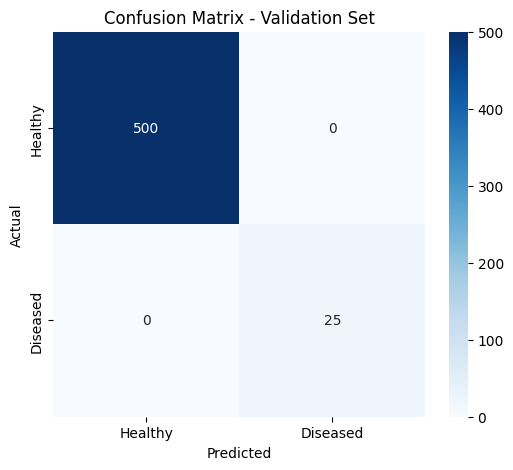


 Evaluating model on Test set...

 Test Results:
    Accuracy:  0.9981
    Precision: 1.0000
    Recall:    0.9600
    F1-Score:  0.9796
    ROC-AUC:   0.9999

 Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       500
    Diseased       1.00      0.96      0.98        25

    accuracy                           1.00       525
   macro avg       1.00      0.98      0.99       525
weighted avg       1.00      1.00      1.00       525



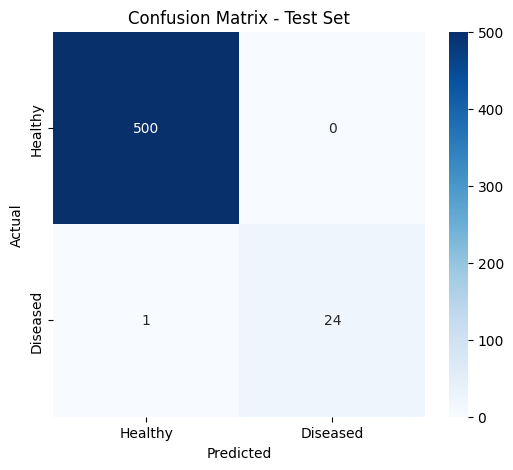


 Testing prediction on sample image...


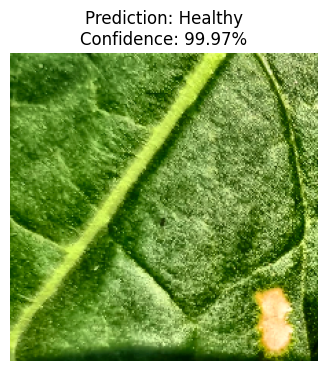

 Prediction: Healthy (Confidence: 99.97%)
 Model evaluation completed!


In [ ]:
# Cell 10: Model Evaluation
# ===============================================

from sklearn.metrics import classification_report, roc_auc_score

def evaluate_model(model, dataset, dataset_name="Test"):
    """Evaluate model performance"""

    print(f"\n Evaluating model on {dataset_name} set...")

    y_true = []
    y_pred_proba = []
    y_pred = []

    # Collect predictions
    for images, labels in dataset:
        preds = model.predict(images, verbose=0).flatten()
        y_true.extend(labels.numpy())
        y_pred_proba.extend(preds)
        y_pred.extend((preds > 0.5).astype(int))

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_pred_proba)
    except:
        auc = 0.0

    print(f"\n {dataset_name} Results:")
    print(f"    Accuracy:  {accuracy:.4f}")
    print(f"    Precision: {precision:.4f}")
    print(f"    Recall:    {recall:.4f}")
    print(f"    F1-Score:  {f1:.4f}")
    print(f"    ROC-AUC:   {auc:.4f}")

    # Classification report
    print(f"\n Classification Report:")
    print(classification_report(y_true, y_pred,
                              target_names=['Healthy', 'Diseased'],
                              zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Healthy', 'Diseased'],
                yticklabels=['Healthy', 'Diseased'])
    plt.title(f'Confusion Matrix - {dataset_name} Set')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': auc
    }

def predict_single_image(model, image_path):
    """Predict disease on a single image"""
    try:
        # Load and preprocess image
        img = tf.keras.preprocessing.image.load_img(
            image_path, target_size=CONFIG['IMG_SIZE'][:2]
        )
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0) / 255.0

        # Make prediction
        prediction = model.predict(img_array, verbose=0)[0][0]
        predicted_class = 'Diseased' if prediction > 0.5 else 'Healthy'
        confidence = prediction if prediction > 0.5 else 1 - prediction

        # Display result
        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.title(f'Prediction: {predicted_class}\nConfidence: {confidence:.2%}')
        plt.axis('off')
        plt.show()

        print(f" Prediction: {predicted_class} (Confidence: {confidence:.2%})")

        return predicted_class, confidence

    except Exception as e:
        print(f" Error predicting image: {e}")
        return None, None

# Evaluate the model
if model is not None and val_dataset is not None:

    print(" Evaluating trained model...")

    # Evaluate on validation set
    val_metrics = evaluate_model(model, val_dataset, "Validation")

    # Evaluate on test set if available
    if test_dataset is not None:
        test_metrics = evaluate_model(model, test_dataset, "Test")

    # Test prediction on a sample image
    if X_test is not None and len(X_test) > 0:
        print("\n Testing prediction on sample image...")
        sample_image = X_test[0]
        predict_single_image(model, sample_image)

    print(" Model evaluation completed!")

else:
    print(" Cannot evaluate model - missing model or data")